### Figure 3
with all lapse-rate final simulations

created by Cassie Lumbrazo\
last updated: Sept 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.dates as mdates

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [3]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [4]:
# HRRR-AK Files First 
ds_snowpack_hrrrak_ppsa, header_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_tram, header_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_tram_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_heen, header_hrrrak_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/hrrrak_heen_WY2020-WY2025_base.smet")

# HRRR-AK Lapse-rate Files 
ds_snowpack_hrrrak_lapserate_ppsa, header_hrrrak_lapserate_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_lapserate_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_lapserate_tram, header_hrrrak_lapserate_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_lapserate_tram_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_lapserate_heen, header_hrrrak_lapserate_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/hrrrak_lapserate_heen_WY2020-WY2025_base.smet")

# Met HRRR-AK Files now
ds_snowpack_met_hrrrak_ppsa, header_met_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_ppsa_WY2020-WY2025_base.smet") # ppsa has WY2020-WY2025
ds_snowpack_met_hrrrak_tram, header_met_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_tram_WY2023-WY2025_base.smet") # tram has WY2023-WY2025
ds_snowpack_met_hrrrak_heen, header_met_hrrrak_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/met_hrrrak_heen_WY2020-WY2022_base.smet") # heen doesn't have until 2025 

# Met HRRR-AK Lapse-rate Files
ds_snowpack_met_hrrrak_lapserate_ppsa, header_met_hrrrak_lapserate_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_lapserate_ppsa_WY2020-WY2025_base.smet") # ppsa has WY2020-WY2025
ds_snowpack_met_hrrrak_lapserate_tram, header_met_hrrrak_lapserate_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_lapserate_tram_WY2023-WY2025_base.smet")
ds_snowpack_met_hrrrak_lapserate_heen, header_met_hrrrak_lapserate_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/met_hrrrak_lapserate_heen_WY2020-WY2022_base.smet") # heen doesn't have until 2025

/tmp/ipykernel_1466158/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1466158/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


/tmp/ipykernel_1466158/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1466158/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1466158/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1466158/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1466158/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df 

### Open Observations

In [5]:
# open observations

# HEEN 
file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/heen_met_2016_2026_cleaned_v1.nc"
ds_obs_heen = xr.open_dataset(file_heen)
ds_obs_heen = ds_obs_heen.sel(time=slice("2019-10-01", "2025-09-30"))

#PPSA 
file_ppsa = "/hdd/snow_hydrology/met_station/ppsa2/pppsa_met_station_data_synoptic_2026-03-20" 
ds_obs_ppsa = xr.open_dataset(file_ppsa)
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2019-10-01", "2025-09-30"))


# TRAM 
file_tram = "/hdd/snow_hydrology/met_station/tram/tram_met_station_data_synoptic_2026-03-20"  
ds_obs_tram = xr.open_dataset(file_tram)
ds_obs_tram = ds_obs_tram.sel(time=slice("2019-10-01", "2025-09-30"))

In [6]:
# pick colors for each site and stick to them across all plots
ppsa_color = 'darkviolet'
tram_color = 'maroon'
heen_color = 'teal'

# color hrrr-ak model 
hrrrak_color = 'tab:blue'
hrrrak_lapserate_color = 'tab:orange'
met_hrrrak_color = 'tab:green'
obs_color = 'tab:gray'

Cut to just three years each

In [7]:
ds_obs_heen = ds_obs_heen.sel(time=slice("2019-09-01", "2022-09-30"))
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2022-09-01", "2025-09-30"))
ds_obs_tram = ds_obs_tram.sel(time=slice("2022-09-01", "2025-09-30"))

# Figure 3

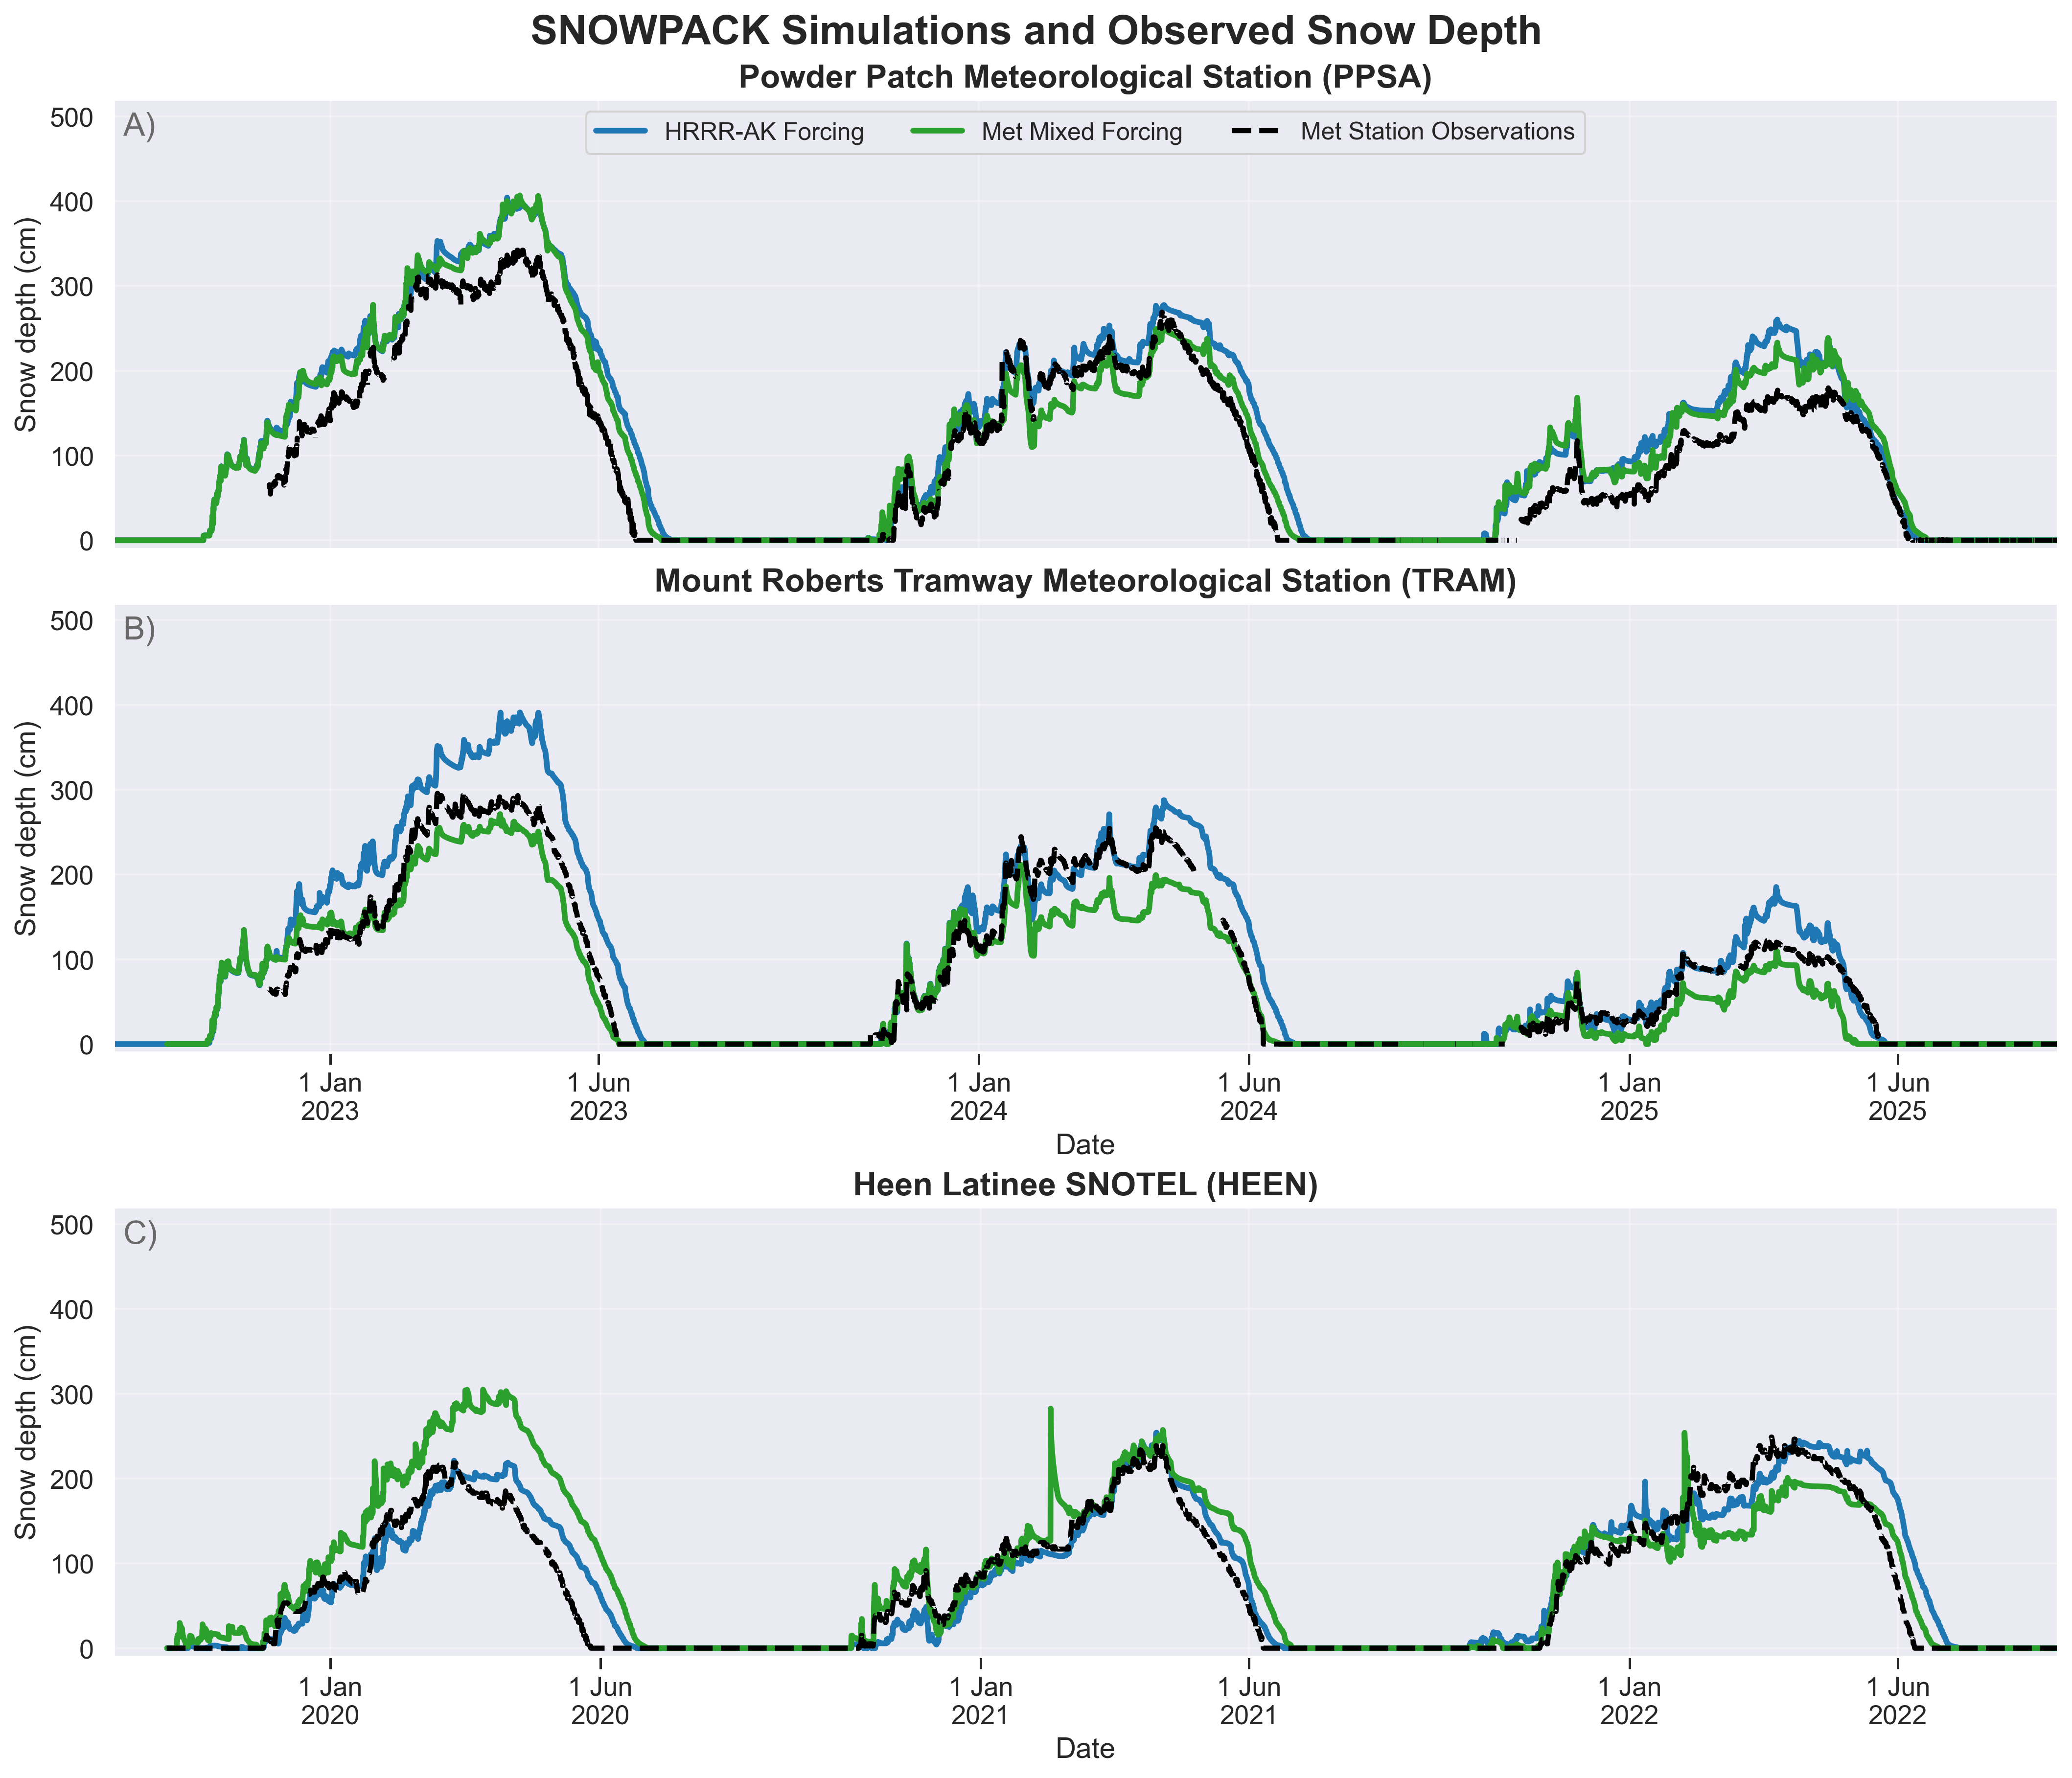

In [11]:
# ============================================================
# Select periods
# ============================================================

# HEEN -> WY2020-WY2022
heen_start = "2019-09-01"
heen_end   = "2022-08-30"

# PPSA + TRAM -> WY2023-WY2025
modern_start = "2022-09-01"
modern_end   = "2025-08-30"

# ------------------------------------------------------------
# Observations
# ------------------------------------------------------------

ds_obs_heen_plot = ds_obs_heen.sel(time=slice(heen_start, heen_end))
ds_obs_ppsa_plot = ds_obs_ppsa.sel(time=slice(modern_start, modern_end))
ds_obs_tram_plot = ds_obs_tram.sel(time=slice(modern_start, modern_end))

# ------------------------------------------------------------
# HRRR-AK simulations
# ------------------------------------------------------------

ds_snowpack_hrrrak_heen_plot = ds_snowpack_hrrrak_heen.sel(timestamp=slice(heen_start, heen_end))
ds_snowpack_hrrrak_ppsa_plot = ds_snowpack_hrrrak_ppsa.sel(timestamp=slice(modern_start, modern_end))
ds_snowpack_hrrrak_tram_plot = ds_snowpack_hrrrak_tram.sel(timestamp=slice(modern_start, modern_end))

# ------------------------------------------------------------
# HRRR-AK lapse-rate simulations
# ------------------------------------------------------------

ds_snowpack_hrrrak_lapserate_heen_plot = ds_snowpack_hrrrak_lapserate_heen.sel(timestamp=slice(heen_start, heen_end))
ds_snowpack_hrrrak_lapserate_ppsa_plot = ds_snowpack_hrrrak_lapserate_ppsa.sel(timestamp=slice(modern_start, modern_end))
ds_snowpack_hrrrak_lapserate_tram_plot = ds_snowpack_hrrrak_lapserate_tram.sel(timestamp=slice(modern_start, modern_end))

# ------------------------------------------------------------
# Mixed met forcing simulations
# ------------------------------------------------------------

ds_snowpack_met_hrrrak_heen_plot = ds_snowpack_met_hrrrak_heen.sel(timestamp=slice(heen_start, heen_end))
ds_snowpack_met_hrrrak_ppsa_plot = ds_snowpack_met_hrrrak_ppsa.sel(timestamp=slice(modern_start, modern_end))
ds_snowpack_met_hrrrak_tram_plot = ds_snowpack_met_hrrrak_tram.sel(timestamp=slice(modern_start, modern_end))

# ------------------------------------------------------------
# Mixed met + HRRR-AK lapse-rate temperature fill simulations
# ------------------------------------------------------------

ds_snowpack_met_hrrrak_lapserate_heen_plot = (
    ds_snowpack_met_hrrrak_lapserate_heen.sel(timestamp=slice(heen_start, heen_end))
)

ds_snowpack_met_hrrrak_lapserate_ppsa_plot = (
    ds_snowpack_met_hrrrak_lapserate_ppsa.sel(timestamp=slice(modern_start, modern_end))
)

ds_snowpack_met_hrrrak_lapserate_tram_plot = (
    ds_snowpack_met_hrrrak_lapserate_tram.sel(timestamp=slice(modern_start, modern_end))
)


# ============================================================
# Adjustable manuscript-style plotting parameters
# ============================================================

fig_width = 14
fig_height = 12
dpi = 300

title_fontsize = 20
subplot_title_fontsize = 16
axis_label_fontsize = 14
tick_fontsize = 13
legend_fontsize = 12

model_linewidth = 2.8
obs_linewidth = 2.5

major_tick_length = 6
major_tick_width = 1.2

spine_width = 1.2


# ============================================================
# Colors
# ============================================================

hrrrak_color = "tab:blue"
met_mixed_color = "tab:green"
obs_color = "black"


# ============================================================
# Create figure
# ============================================================

fig = plt.figure(
    figsize=(fig_width, fig_height),
    dpi=dpi,
    constrained_layout=True
)

ax1 = plt.subplot(3, 1, 1)
ax2 = plt.subplot(3, 1, 2, sharey=ax1)
ax3 = plt.subplot(3, 1, 3, sharey=ax1)


# ============================================================
# Site configuration
# ============================================================

sites = [
    {
        "ax": ax1,
        "site_name": "Powder Patch Meteorological Station (PPSA)",
        "hrrr_ds": ds_snowpack_hrrrak_lapserate_ppsa_plot,
        "met_ds": ds_snowpack_met_hrrrak_lapserate_ppsa_plot,
        "obs_ds": ds_obs_ppsa_plot,
        "xmin": modern_start,
        "xmax": modern_end,
    },
    {
        "ax": ax2,
        "site_name": "Mount Roberts Tramway Meteorological Station (TRAM)",
        "hrrr_ds": ds_snowpack_hrrrak_lapserate_tram_plot,
        "met_ds": ds_snowpack_met_hrrrak_lapserate_tram_plot,
        "obs_ds": ds_obs_tram_plot,
        "xmin": modern_start,
        "xmax": modern_end,
    },
    {
        "ax": ax3,
        "site_name": "Heen Latinee SNOTEL (HEEN)",
        "hrrr_ds": ds_snowpack_hrrrak_lapserate_heen_plot,
        "met_ds": ds_snowpack_met_hrrrak_lapserate_heen_plot,
        "obs_ds": ds_obs_heen_plot,
        "xmin": heen_start,
        "xmax": heen_end,
    },
]


# ============================================================
# Plot each site
# ============================================================

for site in sites:

    ax = site["ax"]

    # --------------------------------------------------------
    # HRRR-AK lapse-rate corrected forcing
    # --------------------------------------------------------

    site["hrrr_ds"].HS_mod.plot(
        ax=ax,
        color=hrrrak_color,
        linewidth=model_linewidth,
        linestyle="-",
        label="HRRR-AK Forcing",
    )

    # --------------------------------------------------------
    # Mixed met forcing with lapse-rate corrected HRRR-AK TA fill
    # --------------------------------------------------------

    site["met_ds"].HS_mod.plot(
        ax=ax,
        color=met_mixed_color,
        linewidth=model_linewidth,
        linestyle="-",
        label="Met Mixed Forcing",
    )

    # --------------------------------------------------------
    # Observed snow depth
    # --------------------------------------------------------

    site["obs_ds"].hs.plot(
        ax=ax,
        color=obs_color,
        linestyle="--",
        linewidth=obs_linewidth,
        label="Met Station Observations",
    )

    # --------------------------------------------------------
    # Axis limits
    # --------------------------------------------------------

    ax.set_xlim(
        pd.Timestamp(site["xmin"]),
        pd.Timestamp(site["xmax"])
    )

    # --------------------------------------------------------
    # Titles and labels
    # --------------------------------------------------------

    ax.set_title(
        site["site_name"],
        fontsize=subplot_title_fontsize,
        fontweight="bold",
    )

    ax.set_ylabel(
        "Snow depth (cm)",
        fontsize=axis_label_fontsize,
    )

    # --------------------------------------------------------
    # Tick formatting
    # --------------------------------------------------------

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=tick_fontsize,
        length=major_tick_length,
        width=major_tick_width,
    )

    # --------------------------------------------------------
    # Spine thickness
    # --------------------------------------------------------

    for spine in ax.spines.values():
        spine.set_linewidth(spine_width)

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(alpha=0.3)


# ============================================================
# Legend
# ============================================================

# One legend is sufficient because all panels contain the same datasets.
ax1.legend(
    fontsize=legend_fontsize,
    loc="upper center",
    frameon=True,
    ncol=3,
)


# ============================================================
# X-axis formatting
# ============================================================

for ax in [ax1, ax2, ax3]:

    # Create a separate locator/formatter for each axis
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(bymonth=[1, 6])
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%-d %b\n%Y")
    )

    ax.set_xlabel(
        "Date",
        fontsize=axis_label_fontsize
    )

    ax.tick_params(
        axis="x",
        which="major",
        bottom=True,
        labelbottom=True,
        labelsize=tick_fontsize,
        length=major_tick_length,
        width=major_tick_width,
    )

    for label in ax.get_xticklabels():
        label.set_visible(True)


# Remove x-axis ticks and labels from panel A
ax1.set_xlabel("")

ax1.tick_params(
    axis="x",
    which="both",
    bottom=False,
    top=False,
    labelbottom=False,
)


# ============================================================
# Shared y-axis limits
# ============================================================

ax1.set_ylim(-10, 520)


# ============================================================
# Figure title
# ============================================================

fig.suptitle(
    "SNOWPACK Simulations and Observed Snow Depth",
    fontsize=title_fontsize,
    fontweight="bold",
)


# ============================================================
# Add subplot labels
# ============================================================

xloc = 0.005
yloc = 0.92

ax1.text(
    xloc,
    yloc,
    "A)",
    transform=ax1.transAxes,
    fontsize=subplot_title_fontsize,
    color="dimgrey",
)

ax2.text(
    xloc,
    yloc,
    "B)",
    transform=ax2.transAxes,
    fontsize=subplot_title_fontsize,
    color="dimgrey",
)

ax3.text(
    xloc,
    yloc,
    "C)",
    transform=ax3.transAxes,
    fontsize=subplot_title_fontsize,
    color="dimgrey",
)


# ============================================================
# Save figure
# ============================================================

plt.savefig(
    "/home/cassie/python/repos/snow_modeling_point/figures/figure3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Now, create a supplementary figure for the paper with all the simulations (color continous from paper)


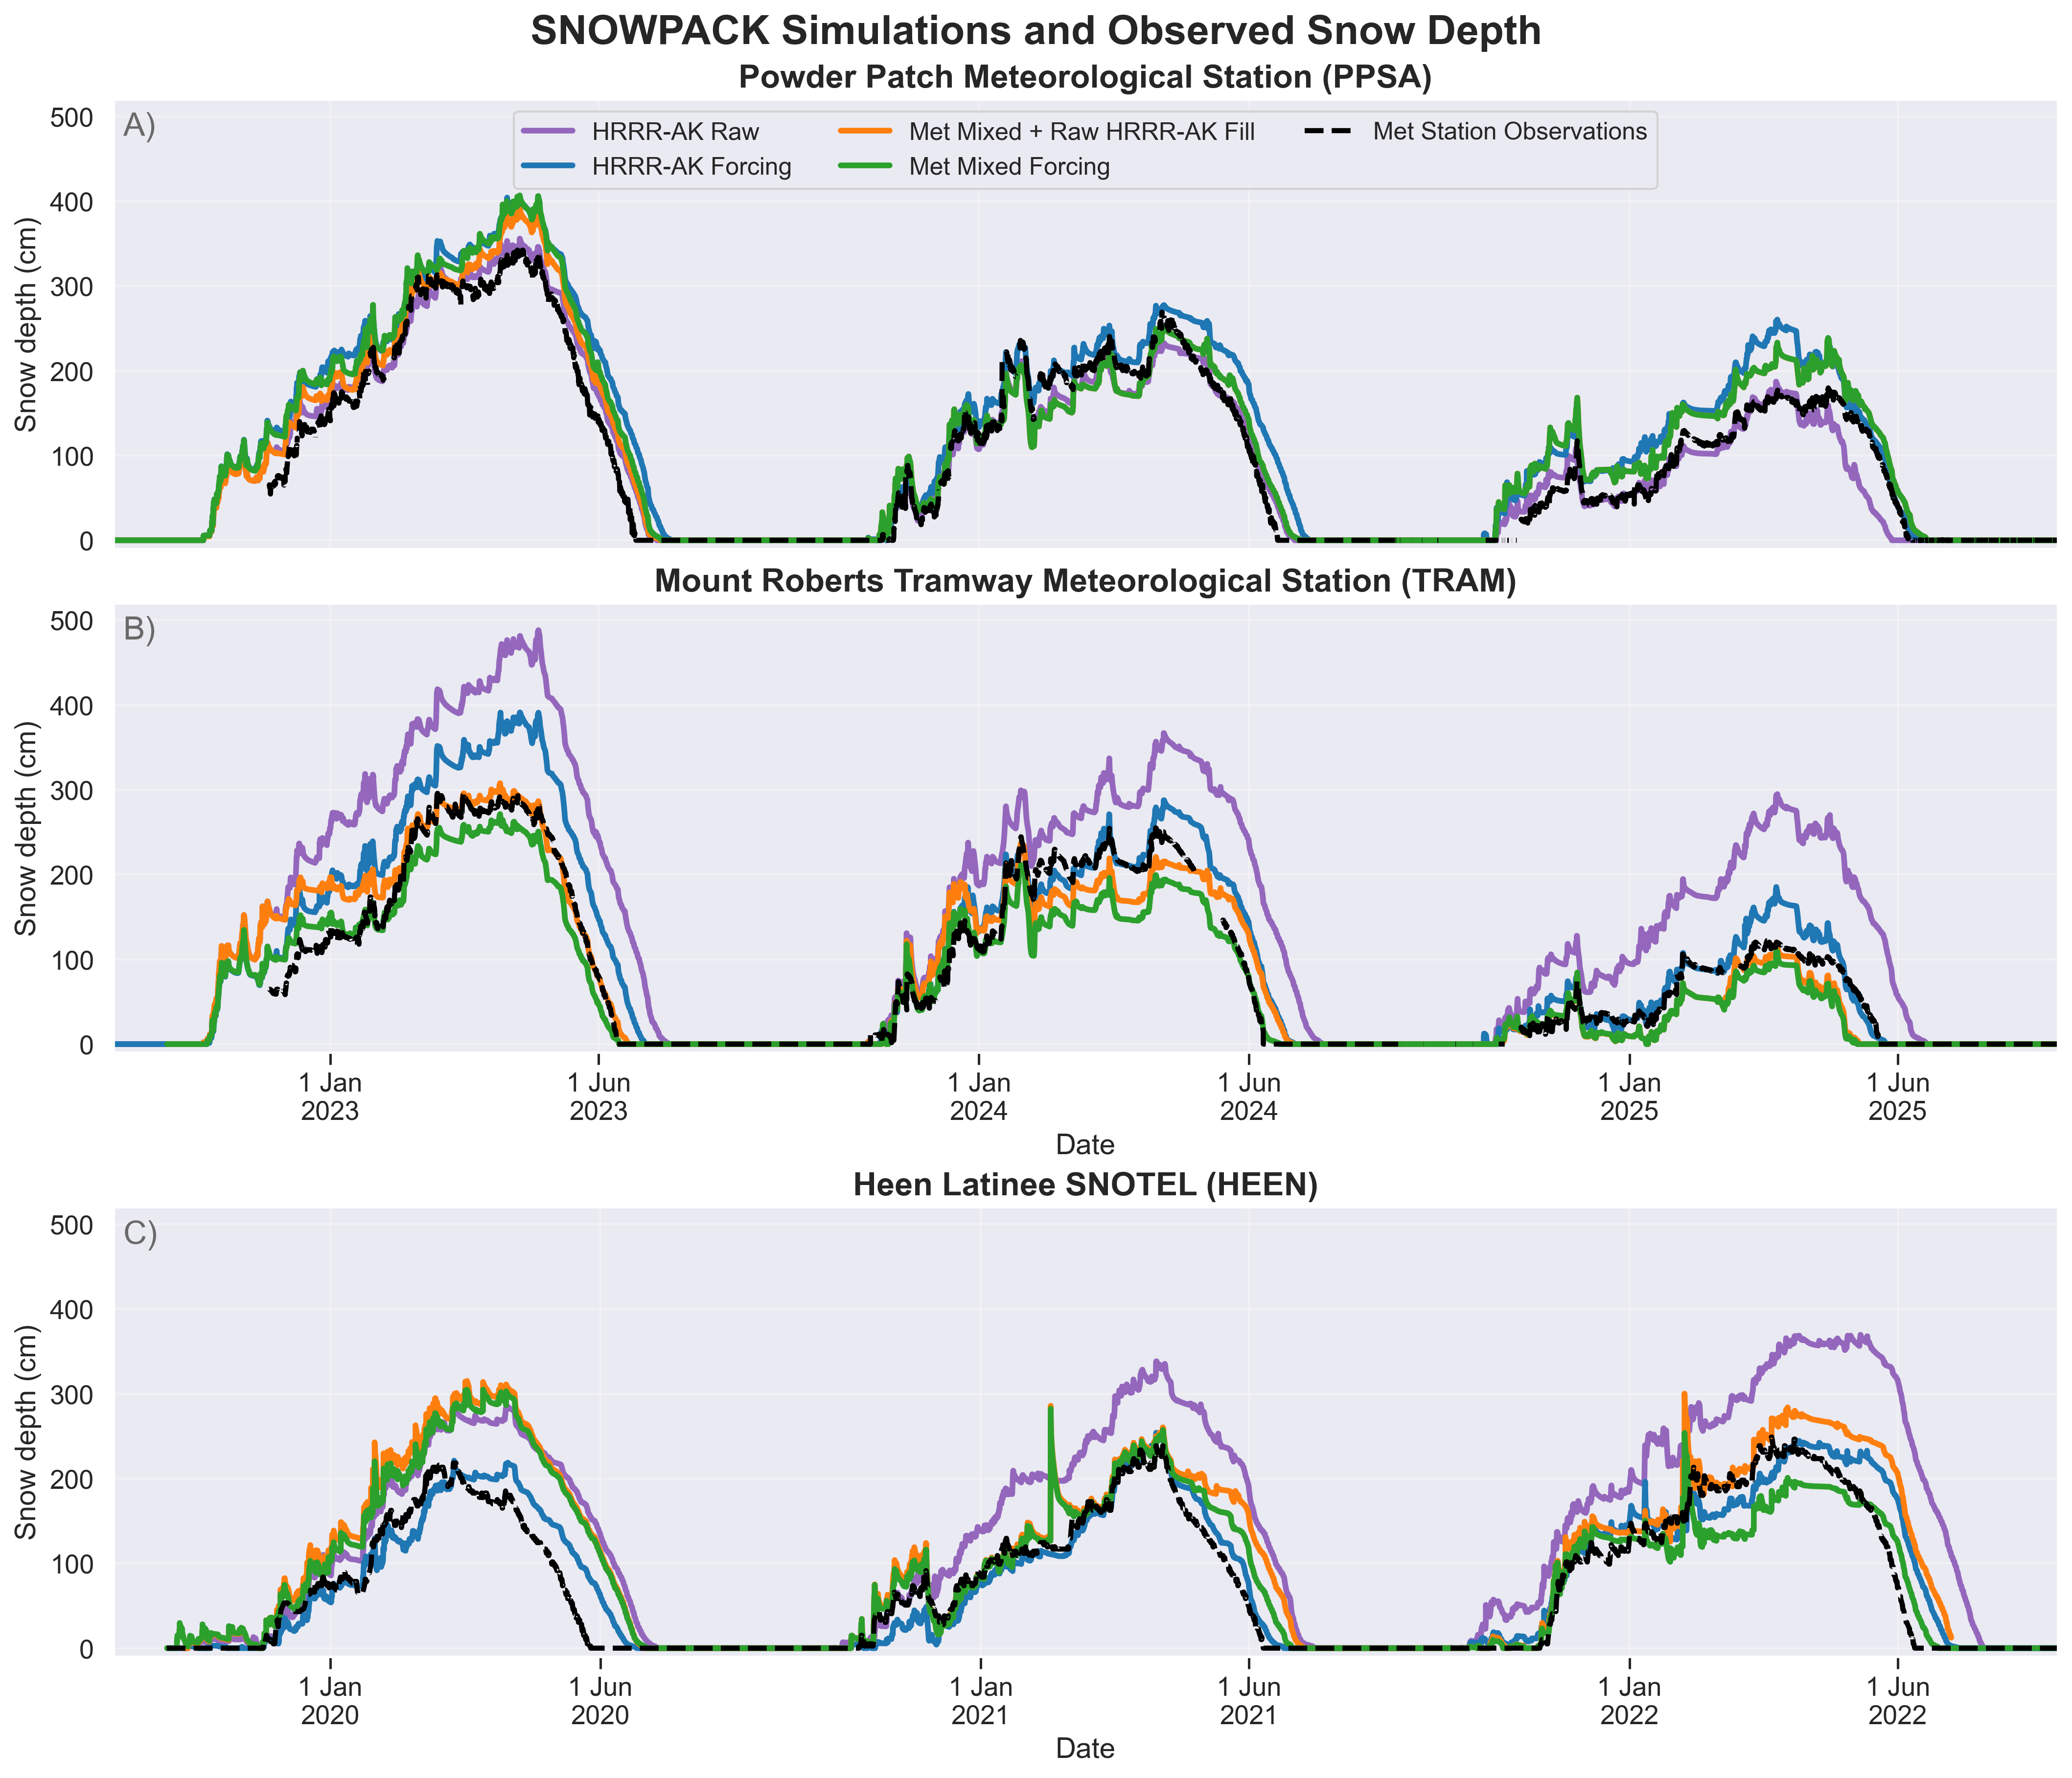

In [12]:
# ============================================================
# Select periods
# ============================================================

# HEEN -> WY2020-WY2022
heen_start = "2019-09-01"
heen_end   = "2022-08-30"

# PPSA + TRAM -> WY2023-WY2025
modern_start = "2022-09-01"
modern_end   = "2025-08-30"


# ------------------------------------------------------------
# Observations
# ------------------------------------------------------------

ds_obs_heen_plot = ds_obs_heen.sel(
    time=slice(heen_start, heen_end)
)

ds_obs_ppsa_plot = ds_obs_ppsa.sel(
    time=slice(modern_start, modern_end)
)

ds_obs_tram_plot = ds_obs_tram.sel(
    time=slice(modern_start, modern_end)
)


# ------------------------------------------------------------
# HRRR-AK raw simulations
# ------------------------------------------------------------

ds_snowpack_hrrrak_heen_plot = (
    ds_snowpack_hrrrak_heen.sel(
        timestamp=slice(heen_start, heen_end)
    )
)

ds_snowpack_hrrrak_ppsa_plot = (
    ds_snowpack_hrrrak_ppsa.sel(
        timestamp=slice(modern_start, modern_end)
    )
)

ds_snowpack_hrrrak_tram_plot = (
    ds_snowpack_hrrrak_tram.sel(
        timestamp=slice(modern_start, modern_end)
    )
)


# ------------------------------------------------------------
# HRRR-AK lapse-rate corrected simulations
# ------------------------------------------------------------

ds_snowpack_hrrrak_lapserate_heen_plot = (
    ds_snowpack_hrrrak_lapserate_heen.sel(
        timestamp=slice(heen_start, heen_end)
    )
)

ds_snowpack_hrrrak_lapserate_ppsa_plot = (
    ds_snowpack_hrrrak_lapserate_ppsa.sel(
        timestamp=slice(modern_start, modern_end)
    )
)

ds_snowpack_hrrrak_lapserate_tram_plot = (
    ds_snowpack_hrrrak_lapserate_tram.sel(
        timestamp=slice(modern_start, modern_end)
    )
)


# ------------------------------------------------------------
# Mixed met forcing with raw HRRR-AK fill
# ------------------------------------------------------------

ds_snowpack_met_hrrrak_heen_plot = (
    ds_snowpack_met_hrrrak_heen.sel(
        timestamp=slice(heen_start, heen_end)
    )
)

ds_snowpack_met_hrrrak_ppsa_plot = (
    ds_snowpack_met_hrrrak_ppsa.sel(
        timestamp=slice(modern_start, modern_end)
    )
)

ds_snowpack_met_hrrrak_tram_plot = (
    ds_snowpack_met_hrrrak_tram.sel(
        timestamp=slice(modern_start, modern_end)
    )
)


# ------------------------------------------------------------
# Mixed met forcing with lapse-rate corrected HRRR-AK TA fill
# ------------------------------------------------------------

ds_snowpack_met_hrrrak_lapserate_heen_plot = (
    ds_snowpack_met_hrrrak_lapserate_heen.sel(
        timestamp=slice(heen_start, heen_end)
    )
)

ds_snowpack_met_hrrrak_lapserate_ppsa_plot = (
    ds_snowpack_met_hrrrak_lapserate_ppsa.sel(
        timestamp=slice(modern_start, modern_end)
    )
)

ds_snowpack_met_hrrrak_lapserate_tram_plot = (
    ds_snowpack_met_hrrrak_lapserate_tram.sel(
        timestamp=slice(modern_start, modern_end)
    )
)


# ============================================================
# Adjustable supplementary-figure plotting parameters
# ============================================================

fig_width = 14
fig_height = 12
dpi = 300

title_fontsize = 20
subplot_title_fontsize = 16
axis_label_fontsize = 14
tick_fontsize = 13
legend_fontsize = 12

model_linewidth = 2.8
obs_linewidth = 2.5

major_tick_length = 6
major_tick_width = 1.2

spine_width = 1.2


# ============================================================
# Colors
# ============================================================

# Main-manuscript forcing colors
hrrrak_lapserate_color = "tab:blue"
met_hrrrak_lapserate_color = "tab:green"

# Additional simulations shown only in supplementary figure
hrrrak_raw_color = "tab:purple"
met_hrrrak_raw_color = "tab:orange"

# Observations
obs_color = "black"


# ============================================================
# Create figure
# ============================================================

fig = plt.figure(
    figsize=(fig_width, fig_height),
    dpi=dpi,
    constrained_layout=True
)

ax1 = plt.subplot(3, 1, 1)
ax2 = plt.subplot(3, 1, 2, sharey=ax1)
ax3 = plt.subplot(3, 1, 3, sharey=ax1)


# ============================================================
# Site configuration
# ============================================================

sites = [
    {
        "ax": ax1,
        "site_name": "Powder Patch Meteorological Station (PPSA)",

        # Raw forcing simulations
        "hrrr_raw_ds": ds_snowpack_hrrrak_ppsa_plot,
        "met_raw_ds": ds_snowpack_met_hrrrak_ppsa_plot,

        # Lapse-rate forcing simulations
        "hrrr_lapserate_ds":
            ds_snowpack_hrrrak_lapserate_ppsa_plot,

        "met_lapserate_ds":
            ds_snowpack_met_hrrrak_lapserate_ppsa_plot,

        # Observations
        "obs_ds": ds_obs_ppsa_plot,

        "xmin": modern_start,
        "xmax": modern_end,
    },

    {
        "ax": ax2,
        "site_name":
            "Mount Roberts Tramway Meteorological Station (TRAM)",

        # Raw forcing simulations
        "hrrr_raw_ds": ds_snowpack_hrrrak_tram_plot,
        "met_raw_ds": ds_snowpack_met_hrrrak_tram_plot,

        # Lapse-rate forcing simulations
        "hrrr_lapserate_ds":
            ds_snowpack_hrrrak_lapserate_tram_plot,

        "met_lapserate_ds":
            ds_snowpack_met_hrrrak_lapserate_tram_plot,

        # Observations
        "obs_ds": ds_obs_tram_plot,

        "xmin": modern_start,
        "xmax": modern_end,
    },

    {
        "ax": ax3,
        "site_name": "Heen Latinee SNOTEL (HEEN)",

        # Raw forcing simulations
        "hrrr_raw_ds": ds_snowpack_hrrrak_heen_plot,
        "met_raw_ds": ds_snowpack_met_hrrrak_heen_plot,

        # Lapse-rate forcing simulations
        "hrrr_lapserate_ds":
            ds_snowpack_hrrrak_lapserate_heen_plot,

        "met_lapserate_ds":
            ds_snowpack_met_hrrrak_lapserate_heen_plot,

        # Observations
        "obs_ds": ds_obs_heen_plot,

        "xmin": heen_start,
        "xmax": heen_end,
    },
]


# ============================================================
# Plot each site
# ============================================================

for site in sites:

    ax = site["ax"]

    # --------------------------------------------------------
    # HRRR-AK raw forcing
    # --------------------------------------------------------

    site["hrrr_raw_ds"].HS_mod.plot(
        ax=ax,
        color=hrrrak_raw_color,
        linewidth=model_linewidth,
        linestyle="-",
        label="HRRR-AK Raw",
    )


    # --------------------------------------------------------
    # HRRR-AK lapse-rate corrected forcing
    # Main manuscript simulation
    # --------------------------------------------------------

    site["hrrr_lapserate_ds"].HS_mod.plot(
        ax=ax,
        color=hrrrak_lapserate_color,
        linewidth=model_linewidth,
        linestyle="-",
        label="HRRR-AK Forcing",
    )


    # --------------------------------------------------------
    # Met mixed forcing with raw HRRR-AK fill
    # --------------------------------------------------------

    site["met_raw_ds"].HS_mod.plot(
        ax=ax,
        color=met_hrrrak_raw_color,
        linewidth=model_linewidth,
        linestyle="-",
        label="Met Mixed + Raw HRRR-AK Fill",
    )


    # --------------------------------------------------------
    # Met mixed forcing with lapse-rate corrected HRRR-AK TA fill
    # Main manuscript simulation
    # --------------------------------------------------------

    site["met_lapserate_ds"].HS_mod.plot(
        ax=ax,
        color=met_hrrrak_lapserate_color,
        linewidth=model_linewidth,
        linestyle="-",
        label="Met Mixed Forcing",
    )


    # --------------------------------------------------------
    # Met station observations
    # --------------------------------------------------------

    site["obs_ds"].hs.plot(
        ax=ax,
        color=obs_color,
        linestyle="--",
        linewidth=obs_linewidth,
        label="Met Station Observations",
    )


    # --------------------------------------------------------
    # Axis limits
    # --------------------------------------------------------

    ax.set_xlim(
        pd.Timestamp(site["xmin"]),
        pd.Timestamp(site["xmax"])
    )


    # --------------------------------------------------------
    # Titles and labels
    # --------------------------------------------------------

    ax.set_title(
        site["site_name"],
        fontsize=subplot_title_fontsize,
        fontweight="bold",
    )

    ax.set_ylabel(
        "Snow depth (cm)",
        fontsize=axis_label_fontsize,
    )


    # --------------------------------------------------------
    # Tick formatting
    # --------------------------------------------------------

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=tick_fontsize,
        length=major_tick_length,
        width=major_tick_width,
    )


    # --------------------------------------------------------
    # Spine thickness
    # --------------------------------------------------------

    for spine in ax.spines.values():
        spine.set_linewidth(spine_width)


    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(alpha=0.3)


# ============================================================
# Legend
# ============================================================

# One shared-style legend is sufficient because all three
# panels contain the same simulation types.

ax1.legend(
    fontsize=legend_fontsize,
    loc="upper center",
    frameon=True,
    ncol=3,
)


# ============================================================
# X-axis formatting
# ============================================================

for ax in [ax1, ax2, ax3]:

    # Create a separate locator/formatter for each axis
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(
            bymonth=[1, 6]
        )
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter(
            "%-d %b\n%Y"
        )
    )

    ax.set_xlabel(
        "Date",
        fontsize=axis_label_fontsize
    )

    ax.tick_params(
        axis="x",
        which="major",
        bottom=True,
        labelbottom=True,
        labelsize=tick_fontsize,
        length=major_tick_length,
        width=major_tick_width,
    )

    for label in ax.get_xticklabels():
        label.set_visible(True)


# ============================================================
# Remove x-axis ticks and labels from panel A
# ============================================================

ax1.set_xlabel("")

ax1.tick_params(
    axis="x",
    which="both",
    bottom=False,
    top=False,
    labelbottom=False,
)


# ============================================================
# Shared y-axis limits
# ============================================================

ax1.set_ylim(-10, 520)


# ============================================================
# Figure title
# ============================================================

fig.suptitle(
    "SNOWPACK Simulations and Observed Snow Depth",
    fontsize=title_fontsize,
    fontweight="bold",
)


# ============================================================
# Add subplot labels
# ============================================================

xloc = 0.005
yloc = 0.92

ax1.text(
    xloc,
    yloc,
    "A)",
    transform=ax1.transAxes,
    fontsize=subplot_title_fontsize,
    color="dimgrey",
)

ax2.text(
    xloc,
    yloc,
    "B)",
    transform=ax2.transAxes,
    fontsize=subplot_title_fontsize,
    color="dimgrey",
)

ax3.text(
    xloc,
    yloc,
    "C)",
    transform=ax3.transAxes,
    fontsize=subplot_title_fontsize,
    color="dimgrey",
)


# ============================================================
# Save figure
# ============================================================

plt.savefig(
    "/home/cassie/python/repos/snow_modeling_point/figures/figure3_supplementary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()